# Seville CMIP6 SSP2-4.5 Projection EDA (2026-2045)

Applies the same processing and indicator-calculation pipeline used in `seville_cmip6_projection_eda.ipynb`
(the SSP5-8.5 notebook, itself a port of `seville_era5_eda.ipynb`) to the CMIP6 `cmcc_esm2` SSP2-4.5
projection pulled by `pull_cmip6_projections_ssp245.py`. Deliberately the **same model** as the SSP5-8.5
notebook -- an earlier SSP2-4.5 pull used `ec_earth3_cc` instead (see `fetch_cmip6_projections.py`), but
availability of `cmcc_esm2`/`ssp2_4_5`/daily was confirmed against the live CDS constraints endpoint
(`scripts/scenario_scan.py --model cmcc_esm2`) and the data re-pulled with `cmcc_esm2` specifically so
that this notebook's bias correction (Section 12) can reuse the *existing* `cmcc_esm2` historical run
(1990-2014, already pulled for the SSP5-8.5 notebook) rather than requiring a second historical pull --
a model's `historical` experiment doesn't depend on which future SSP is being projected.

Sections that don't apply (6-hourly resampling, wind-direction/rose, sub-daily heat index) are dropped
rather than faked, matching the SSP5-8.5 notebook's own approach; sections that would silently redefine
a "fixed" threshold from the projection data itself (the P90 heatwave threshold) instead load and reuse
the threshold already fit on the ERA5 1990-2020 reference period, per `fixed_reference_period_principle.md`.

**Source data:** `data/seville_cmip6_ssp245_2026_2045.csv` (model `cmcc_esm2`, experiment `ssp2_4_5`,
4 grid points in the Seville bounding box, 2026-01-01 to 2045-12-31).

**Historical reference** (for fixed thresholds and the ERA5-vs-projection comparison):
`../../Historical/eda_outputs/seville/seville_daily.csv` and `annual_summary.csv`, from `seville_era5_eda.ipynb`.

**Known limitations, stated once here rather than repeated throughout:** raw (non-bias-corrected)
CMIP6 output at a single grid box, one model, one scenario -- see `documentation/projection_data_pull_plan.md`
Step 6 and `project_summary.md`'s "illustrative of directional risk rather than definitive climate-model
consensus" framing. Sections 1-11 work entirely with raw output; Section 12 applies an Equidistant CDF
Matching bias correction, and Sections 13-16 recompute every indicator (heatwaves, hot days, wet-day
stats, trends) on that corrected series with an explicit before/after comparison. Full breakdown of what
carries over vs. what doesn't -- including two items (SPI-3, fire-danger) that carried over for SSP5-8.5
but do not yet exist for this scenario -- is in Section 17 below.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

RAW_CSV = Path("../data/seville_cmip6_ssp245_2026_2045.csv")
ERA5_DAILY_CSV = Path("../../Historical/eda_outputs/seville/seville_daily.csv")
ERA5_ANNUAL_CSV = Path("../../Historical/eda_outputs/seville/annual_summary.csv")
OUT = Path("../eda_outputs/seville")
OUT.mkdir(parents=True, exist_ok=True)

# Fixed reference period -- used only to fit thresholds below, never refit on new data.
# See fixed_reference_period_principle.md.
REFERENCE_START, REFERENCE_END = 1990, 2020

## 1. Load the raw CMIP6 pull

`pull_cmip6_projections.py` merges 7 separately-downloaded variables on `(valid_time, lat, lon)`,
but each variable also carries its own 2-valued `bnds` dimension (from `time_bnds`/`lat_bnds`/
`lon_bnds`) that isn't part of the merge key -- 6 successive merges of a 2-valued, unmerged
dimension multiply row count by 2**6 = 64. Every "duplicate" row is value-identical (confirmed by
`nunique()==1` per group before writing this notebook), so it doesn't bias any mean computed
downstream, but it inflates the frame ~64x for no reason and would make row-count sanity checks
misleading if left in. Dropped explicitly below, as a documented QC step.

In [2]:
raw = pd.read_csv(RAW_CSV, parse_dates=["valid_time"])
print(f"raw shape: {raw.shape}")
print(raw.columns.tolist())

BNDS_COLS = ["bnds", "time_bnds", "lat_bnds", "lon_bnds", "height"]
df = raw.drop(columns=[c for c in BNDS_COLS if c in raw.columns]).drop_duplicates().reset_index(drop=True)

n_days = df["valid_time"].nunique()
n_points = df[["lat", "lon"]].drop_duplicates().shape[0]
print(f"deduped shape: {df.shape}  (expected {n_days} days x {n_points} grid points = {n_days * n_points})")
assert df.shape[0] == n_days * n_points, "dedup did not fully resolve the bnds cross-join"
df.head()

raw shape: (29200, 12)
['valid_time', 'lat', 'lon', 'tas', 'tasmax', 'tasmin', 'pr', 'huss', 'sfcWind', 'psl', 'precip_mm_day', 'relative_humidity_pct']
deduped shape: (29200, 12)  (expected 7300 days x 4 grid points = 29200)


,valid_time,lat,lon,tas,tasmax,tasmin,pr,huss,sfcWind,psl,precip_mm_day,relative_humidity_pct
0,2026-01-01,37.225131,353.75,282.16788,287.35815,278.49295,8.092414e-18,0.004601,2.782776,103534.740,6.991846e-13,66.534386
1,2026-01-01,37.225131,355.00,280.62912,286.17508,276.72687,0.000000e+00,0.004364,2.150920,103560.600,0.000000e+00,70.081220
2,2026-01-01,38.167539,353.75,281.66556,286.15634,278.46216,1.022796e-16,0.004662,2.413867,103659.234,8.836954e-12,69.830420
3,2026-01-01,38.167539,355.00,280.86227,284.79480,277.80260,1.168358e-19,0.004462,1.916331,103638.700,1.009462e-14,70.563880
4,2026-01-02,37.225131,353.75,280.75623,285.25900,277.70303,1.452884e-11,0.003420,3.196463,103894.055,1.255292e-06,54.651638


## 2. Physical plausibility check

Same spirit as the ERA5 notebook's bounds check (its section 2), with CMIP6-appropriate ranges:
temperature is still in Kelvin, `pr` is a flux (kg/m2/s, tiny values), `psl` is in Pa, `huss` is
specific humidity (kg/kg, small), `sfcWind` is a scalar speed in m/s.

In [3]:
BOUNDS = {
    "tas": (250, 325), "tasmax": (250, 330), "tasmin": (245, 320),
    "pr": (0, 0.005),           # kg m-2 s-1 -- 0.005 corresponds to ~430 mm/day, a generous upper bound
    "huss": (0, 0.03),
    "sfcWind": (0, 40),
    "psl": (90000, 108000),
    "precip_mm_day": (0, 400),
    "relative_humidity_pct": (0, 100),
}
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    n_bad = (~df[col].between(lo, hi)).sum()
    print(f"{col:24s} range=({df[col].min():.4g}, {df[col].max():.4g})  out-of-bounds={n_bad}")

# precip_mm_day carries tiny floating-point negative noise (~-1e-4) from the flux conversion at
# near-zero rainfall -- clip rather than treat it as a QC failure.
df["precip_mm_day"] = df["precip_mm_day"].clip(lower=0)

tas                      range=(275.1, 313.2)  out-of-bounds=0
tasmax                   range=(278, 319.5)  out-of-bounds=0
tasmin                   range=(272.2, 307.4)  out-of-bounds=0
pr                       range=(-2.327e-19, 0.0005529)  out-of-bounds=28
huss                     range=(0.00164, 0.01867)  out-of-bounds=0
sfcWind                  range=(0.6886, 8.799)  out-of-bounds=0
psl                      range=(9.92e+04, 1.044e+05)  out-of-bounds=0
precip_mm_day            range=(-2.01e-14, 47.77)  out-of-bounds=28
relative_humidity_pct    range=(8.691, 100)  out-of-bounds=0


## 3. Unit conversions

Temperature: the same `- 273.15` Kelvin to Celsius conversion the ERA5 pipeline used. Precipitation,
specific humidity, wind speed, and relative humidity are already in their final units/derived form
(`pull_cmip6_projections.py` did the `pr x 86400` flux conversion and the specific-humidity to RH
Magnus-formula derivation upstream) -- nothing left to convert for those.

In [4]:
df["tas_c"] = df["tas"] - 273.15
df["tasmax_c"] = df["tasmax"] - 273.15
df["tasmin_c"] = df["tasmin"] - 273.15
df[["tas_c", "tasmax_c", "tasmin_c"]].describe()

,tas_c,tasmax_c,tasmin_c
count,29200.000000,29200.000000,29200.000000
mean,21.084843,25.555118,16.819104
std,7.974325,8.461097,7.333978
min,1.991240,4.865380,-0.985420
25%,14.036190,18.066425,10.463553
50%,20.361115,24.735680,16.247940
75%,28.285188,33.180880,23.325250
max,40.008260,46.335870,34.278380


## 4. Grid-point averaging (4 points to 1 daily series)

Same unweighted arithmetic mean the ERA5 pipeline used (no distance/area weighting there either).
Relative humidity is a nonlinear function of temperature, humidity, and pressure, so -- matching
the ERA5 notebook's own discipline of recomputing RH from averaged inputs rather than averaging RH
itself -- it's recomputed here from the grid-averaged `tas`/`huss`/`psl`, using the identical
Magnus-formula derivation `pull_cmip6_projections.py` used per grid point.

In [5]:
BASE = ["tas", "tasmax", "tasmin", "tas_c", "tasmax_c", "tasmin_c",
        "precip_mm_day", "sfcWind", "huss", "psl"]

sev = df.groupby("valid_time")[BASE].mean()

def derive_rh(tas_k, huss, psl_pa):
    """Identical formula to pull_cmip6_projections.py's per-grid-point derivation, applied here
    to the grid-averaged base variables instead -- mirrors the ERA5 notebook's rule of recomputing
    nonlinear quantities from averaged inputs, not averaging the nonlinear output directly."""
    t_c = tas_k - 273.15
    p_hpa = psl_pa / 100.0
    q = huss
    vapor_pressure = q * p_hpa / (0.622 + 0.378 * q)
    sat_vapor_pressure = 6.112 * np.exp(17.62 * t_c / (243.12 + t_c))
    return np.clip(100 * vapor_pressure / sat_vapor_pressure, 0, 100)

sev["relative_humidity_pct"] = derive_rh(sev["tas"], sev["huss"], sev["psl"])
sev.head()

,tas,tasmax,tasmin,tas_c,tasmax_c,tasmin_c,precip_mm_day,sfcWind,huss,psl,relative_humidity_pct
valid_time,,,,,,,,,,,
2026-01-01,281.331208,286.121093,277.871145,8.181208,12.971093,4.721145,2.386558e-12,2.315973,0.004522,103598.31850,69.249906
2026-01-02,279.646867,283.704215,276.682738,6.496868,10.554215,3.532738,6.552390e-07,2.580533,0.003228,103981.92475,55.699061
2026-01-03,278.556315,283.692138,274.791472,5.406315,10.542138,1.641473,1.970690e-13,2.288035,0.002961,104130.74500,55.185205
2026-01-04,279.414170,284.635110,275.463282,6.264170,11.485110,2.313283,0.000000e+00,2.641386,0.003447,103968.73475,60.427096
2026-01-05,280.672565,285.296095,276.924255,7.522565,12.146095,3.774255,7.784667e-10,2.868789,0.004347,103812.15850,69.765200


## 5. Daily frame

CMIP6's `projections-cmip6` dataset already provides true daily `tasmax`/`tasmin`, not an
approximation from sparse sub-daily samples -- so unlike the ERA5 pipeline (which resampled
6-hourly data with `.resample("D").max()/.min()/.sum()`), there's no resampling step here at all;
`sev` (indexed by `valid_time`, already one row per day) *is* the daily frame. Columns are renamed
to match the ERA5 notebook's naming convention so the indicator-calculation code below is close to
a direct port.

One genuine definitional gap: `heat_index_c` here is computed once per day from the single daily
mean temperature/RH CMIP6 provides, not (as in the ERA5 pipeline) the max of six intra-day
heat-index samples -- there's no sub-daily data to take a max over. It is **not** the same quantity
as the historical `heat_index_max_c` and is named differently here to avoid implying otherwise.

In [6]:
def compute_heat_index(t_c, rh):
    """Identical NWS Rothfusz fit used in the ERA5 notebooks (degF internally, converted back to degC)."""
    t_f = t_c * 9 / 5 + 32
    simple = 0.5 * (t_f + 61.0 + (t_f - 68.0) * 1.2 + rh * 0.094)
    hi_f = (-42.379 + 2.04901523 * t_f + 10.14333127 * rh - 0.22475541 * t_f * rh - 6.83783e-3 * t_f**2
            - 5.481717e-2 * rh**2 + 1.22874e-3 * t_f**2 * rh + 8.5282e-4 * t_f * rh**2 - 1.99e-6 * t_f**2 * rh**2)
    return (np.where(t_f < 80, simple, hi_f) - 32) * 5 / 9

daily = pd.DataFrame({
    "tmax_c": sev["tasmax_c"],
    "tmin_c": sev["tasmin_c"],
    "tmean_c": sev["tas_c"],
    "precip_mm_day": sev["precip_mm_day"],
    "wind_avg": sev["sfcWind"],
    "rh_mean_percent": sev["relative_humidity_pct"],
})
daily["dtr_c"] = daily["tmax_c"] - daily["tmin_c"]
daily["heat_index_c"] = compute_heat_index(daily["tmean_c"], daily["rh_mean_percent"])
daily["year"] = daily.index.year
daily["month"] = daily.index.month

daily.to_csv(OUT / "seville_projection_daily.csv")
daily.describe()

,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7.300000e+03,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,25.555118,16.819104,21.084843,7.288562e-01,2.577172,51.753191,8.736014,20.322463,2035.500000,6.526027
std,8.401326,7.269043,7.923148,2.455374e+00,0.850837,20.772525,2.354000,7.906596,5.766676,3.448088
min,6.059038,-0.103717,2.885685,0.000000e+00,0.799677,11.443415,1.488670,0.635411,2026.000000,1.000000
25%,17.983418,10.486730,13.976154,1.008996e-09,1.937112,32.889108,7.205254,13.301511,2030.750000,4.000000
50%,24.738075,16.293048,20.353795,3.415189e-03,2.471389,50.772613,8.868826,19.821261,2035.500000,7.000000
75%,33.264679,23.492108,28.352911,1.709922e-01,3.094404,70.061860,10.429379,27.682279,2040.250000,10.000000
max,44.786968,33.208843,39.131103,3.839222e+01,7.515474,100.000000,15.930617,37.367465,2045.000000,12.000000


## 6. Fixed reference-period thresholds (loaded from ERA5, 1990-2020, never refit here)

The ERA5 notebook's percentile-based heatwave detection computes a calendar-day P90 threshold
(`tmax_c`, +/-7-day window, pooled across years) inline from whatever `daily` frame is in scope. If
that code were copy-pasted unmodified into this notebook, `daily` would be the *projection* frame,
and the P90 baseline would be silently redefined from 2026-2045 data -- exactly the shifting-baseline
failure `fixed_reference_period_principle.md` warns against, and precisely backwards for a
comparison whose entire point is "how do projected hot days compare to the historical normal." The
threshold is instead computed once here from the ERA5 historical daily series, restricted to the
documented 1990-2020 reference period (the ERA5 notebook itself pooled its full 1990-2025 record
when computing this threshold inline -- a minor inconsistency with the documented principle, not
repeated here).

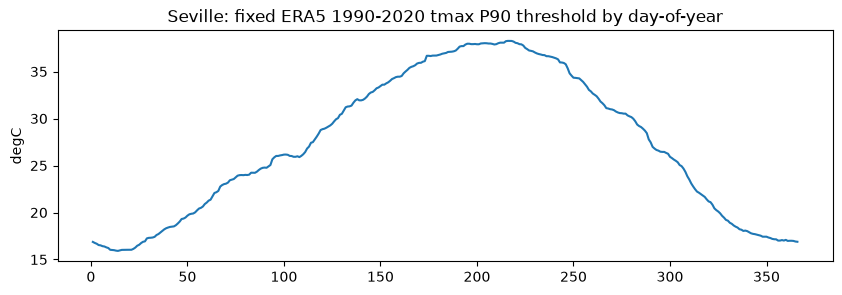

In [7]:
era5_daily = pd.read_csv(ERA5_DAILY_CSV, parse_dates=["valid_time"])
era5_daily["year"] = era5_daily["valid_time"].dt.year
ref = era5_daily[era5_daily["year"].between(REFERENCE_START, REFERENCE_END)].copy()
ref["doy"] = ref["valid_time"].dt.dayofyear

tmax_p90_by_doy = {}
for doy in range(1, 367):
    window = [((doy - 1 + k) % 366) + 1 for k in range(-7, 8)]
    tmax_p90_by_doy[doy] = ref.loc[ref["doy"].isin(window), "tmax_c"].quantile(0.90)

pd.Series(tmax_p90_by_doy).plot(
    title="Seville: fixed ERA5 1990-2020 tmax P90 threshold by day-of-year", figsize=(10, 3))
plt.ylabel("degC")
plt.show()

## 7. Indicator calculation

Hot-day threshold counts and the tropical-night threshold are fixed absolute values in the ERA5
notebook (not fit from data), so they carry over unchanged. Heatwaves apply the fixed P90-by-doy
dict from Section 6 to the *projection's* `tmax_c`, with the same >=3-consecutive-day run
requirement.

In [8]:
THRESH = [30, 33, 35, 37, 40]

d = daily.copy()
d["doy"] = d.index.dayofyear
d["tmax_p90"] = d["doy"].map(tmax_p90_by_doy)
d["exceed"] = d["tmax_c"] > d["tmax_p90"]

grp = (d["exceed"] != d["exceed"].shift()).cumsum()
runs = (d[d["exceed"]]
        .groupby(grp[d["exceed"]])
        .agg(start=("tmax_c", lambda s: s.index.min()),
             length=("tmax_c", "size"),
             peak=("tmax_c", "max"),
             mean_tmax=("tmax_c", "mean")))
heatwaves = runs[runs["length"] >= 3].reset_index(drop=True)
heatwaves["year"] = pd.to_datetime(heatwaves["start"]).dt.year
heatwaves.to_csv(OUT / "seville_projection_heatwave_events.csv", index=False)

hot = pd.DataFrame({
    f"days tmax>={t} C": d.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot["tropical nights tmin>=20 C"] = d.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum()))
hot["days heat index>=35 C"] = d.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum()))

hw_year = heatwaves.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"{len(heatwaves)} heatwave events detected, {heatwaves['year'].nunique()} distinct years")
hot.tail()

323 heatwave events detected, 20 distinct years


,days tmax>=30 C,days tmax>=33 C,days tmax>=35 C,days tmax>=37 C,days tmax>=40 C,tropical nights tmin>=20 C,days heat index>=35 C
year,,,,,,,
2041,114,71,47,17,3,144,0
2042,112,96,76,37,1,119,0
2043,133,107,87,56,14,125,2
2044,127,93,65,36,12,138,6
2045,122,96,77,43,11,133,2


## 8. Wet-day and precipitation extremes

`precip_mm_day` is already a true daily total (`pr x 86400`, done in `pull_cmip6_projections.py`)
-- unlike ERA5's `tp`, which only sampled 4 times a day and needed the `x6` undercount correction
(`PRECIP_SCALE`) before use. That correction does not apply here and is not reused; `precip_mm_day`
is used directly as the "already-scaled" equivalent of the ERA5 notebook's `precip_mm_scaled`. The
1 mm/day wet-day threshold and all four spell/intensity metrics are otherwise unchanged.

In [9]:
WET = 1.0
d["is_wet"] = d["precip_mm_day"] >= WET

def max_dry_run(is_wet):
    dry_flag = (~is_wet).astype(int)
    run_id = (is_wet != is_wet.shift()).cumsum()
    return int(dry_flag.groupby(run_id).sum().max())

wetstats = d.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)
wetstats.tail()

,wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,
2041,65.0,5.821544,38.392224,18.986422,36.0
2042,70.0,6.180585,27.224349,20.945355,103.0
2043,32.0,6.485839,24.770755,21.440818,148.0
2044,60.0,5.561129,23.740299,16.528721,71.0
2045,55.0,4.449709,25.576433,10.964852,66.0


## 9. Annual summary and export

In [10]:
annual = pd.DataFrame({
    "tas_mean": d.groupby("year")["tmean_c"].mean(),
    "rh_mean": d.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d.groupby("year")["wind_avg"].mean(),
    "tas_p95": d.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d.groupby("year")["tmin_c"].mean(),
    "precip_total": d.groupby("year")["precip_mm_day"].sum(),
})

annual_summary = annual.join(hot, how="left").join(hw_year, how="left").join(wetstats, how="left")
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary[col] = annual_summary[col].fillna(0).astype(int)

annual_summary.to_csv(OUT / "seville_projection_annual_summary.csv")
annual_summary

,tas_mean,rh_mean,heat_index_mean,wind_mean,tas_p95,tas_p05,tmax_mean,tmin_mean,precip_total,days tmax>=30 C,...,tropical nights tmin>=20 C,days heat index>=35 C,heatwaves,heatwave days,longest (days),wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,,,,,,,,,,,,,,,,,
2026,20.358732,54.124506,19.700822,2.558928,33.051740,8.606824,24.969644,16.057012,253.257203,119,...,125,0,15,76,12,62.0,3.634935,18.747012,9.550208,46.0
2027,20.413779,57.739611,19.838926,2.621053,33.302455,11.276546,24.611044,16.485737,449.115965,107,...,120,2,11,75,11,76.0,5.572163,21.809676,15.930096,104.0
2028,20.880251,50.173877,20.114247,2.540674,33.313283,9.976471,25.458663,16.536663,181.562151,115,...,125,0,16,80,10,41.0,3.892454,20.364940,9.043322,45.0
2029,20.689230,46.354585,19.681637,2.603717,34.418470,9.315216,25.271252,16.235294,133.137472,131,...,136,3,13,73,11,29.0,3.954094,23.788549,15.328725,98.0
2030,20.741248,44.508030,19.746218,2.666595,33.348833,8.856348,25.300787,16.359538,101.983079,119,...,131,0,17,103,15,19.0,4.313089,11.539323,11.026786,111.0
2031,20.451582,51.339362,19.586212,2.699785,33.380094,8.979011,24.564097,16.408287,353.208648,128,...,139,0,16,78,10,61.0,5.330112,32.989642,14.980566,76.0
2032,20.900937,52.472003,20.115194,2.544316,34.673129,10.884834,25.185317,16.801090,229.546077,104,...,111,4,16,92,19,46.0,4.439438,25.510429,15.186670,128.0
2033,20.929484,51.429184,20.094715,2.465898,34.969285,9.504017,25.700279,16.398686,196.998427,113,...,123,4,16,107,20,50.0,3.538202,16.889838,8.684836,93.0
2034,21.080891,49.696447,20.184714,2.559496,34.099365,9.691185,25.392992,16.822369,212.660962,120,...,133,0,14,77,11,45.0,4.189155,13.332269,10.107455,80.0


## 10. Trend within the projection period (2026-2045)

Same `trend_table()` used throughout the ERA5 notebook (OLS, Theil-Sen, Kendall tau), applied here
to the projection's own 20-year annual series. A 20-year window has much less statistical power
than the ERA5 pipeline's 36-year record, and this is a single model/scenario run, not an ensemble
-- treat any trend found here as suggestive of SSP2-4.5-under-cmcc_esm2 direction, not as a robust,
standalone trend estimate the way the ERA5 trends are.

In [11]:
def trend_table(frame, cols, per_decade=True):
    scale = 10.0 if per_decade else 1.0
    x = frame.index.values.astype(float)
    rows = []
    for c in cols:
        y = frame[c].values.astype(float)
        lr = stats.linregress(x, y)
        ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(y, x, 0.95)
        tau, tau_p = stats.kendalltau(x, y)
        rows.append({
            "variable": c,
            "OLS slope/decade": lr.slope * scale,
            "OLS p-value": lr.pvalue,
            "Theil-Sen slope/decade": ts_slope * scale,
            "Theil-Sen 95% CI low": ts_lo * scale,
            "Theil-Sen 95% CI high": ts_hi * scale,
            "Kendall tau": tau,
            "tau p-value": tau_p,
            "significant (p<0.05)": lr.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("variable")

TREND_COLS = ["tas_mean", "heat_index_mean", "tas_p95", "tmax_mean", "tmin_mean", "precip_total"]
proj_trends = trend_table(annual_summary, TREND_COLS)
proj_trends.to_csv(OUT / "seville_projection_trends.csv")
proj_trends

,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% CI low,Theil-Sen 95% CI high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
tas_mean,0.581166,0.001647,0.654507,0.376667,0.974317,0.589474,0.000142,True
heat_index_mean,0.660618,0.000177,0.689762,0.493984,1.020880,0.610526,0.000073,True
tas_p95,-0.086281,0.777274,0.090404,-0.638210,0.656708,0.063158,0.724636,False
tmax_mean,0.618963,0.007178,0.740482,0.252003,1.117068,0.431579,0.007346,True
tmin_mean,0.575310,0.000641,0.612490,0.248277,0.956696,0.536842,0.000638,True
precip_total,38.004191,0.384487,39.343409,-39.518544,128.042685,0.168421,0.318896,False


## 11. Comparing the projection against the ERA5 historical baseline

`Climate_Indicators_Modeling.ipynb`'s Section 10 sketched this comparison in prose, before the
projection pull existed: extrapolate the ERA5-selected `tmax_mean` model (`ols_last_20yr`, fit on
2006-2025) forward through 2026-2045, and compare it against the CMIP6 projection's own `tmax_mean`
for the same years. The gap between the two is the actual finding -- it separates "how much warming
does the historical trend alone predict" from "how much warming does the SSP2-4.5 scenario, as
realized by cmcc_esm2, actually show."

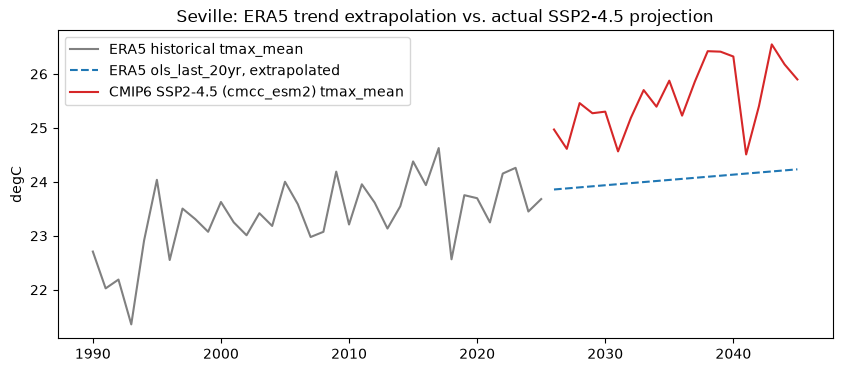

Mean gap 2026-2045: +1.51 degC (positive = SSP2-4.5 projection warmer than the historical-trend extrapolation)


,cmip6_tmax_mean,era5_ols_last20yr_extrapolated,gap_c
year,,,
2026,24.969644,23.858188,1.111456
2027,24.611044,23.877849,0.733195
2028,25.458663,23.897510,1.561153
2029,25.271252,23.917171,1.354081
2030,25.300787,23.936831,1.363955
2031,24.564097,23.956492,0.607605
2032,25.185317,23.976153,1.209164
2033,25.700279,23.995814,1.704465
2034,25.392992,24.015475,1.377518


In [12]:
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")
last20 = era5_annual.loc[2006:2025, "tmax_mean"]
lr = stats.linregress(last20.index.values.astype(float), last20.values.astype(float))

proj_years = annual_summary.index.values.astype(float)
era5_extrapolated = lr.intercept + lr.slope * proj_years

comparison = pd.DataFrame({
    "cmip6_tmax_mean": annual_summary["tmax_mean"],
    "era5_ols_last20yr_extrapolated": era5_extrapolated,
}, index=annual_summary.index)
comparison["gap_c"] = comparison["cmip6_tmax_mean"] - comparison["era5_ols_last20yr_extrapolated"]
comparison.to_csv(OUT / "seville_projection_vs_era5_extrapolation.csv")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(era5_annual.index, era5_annual["tmax_mean"], label="ERA5 historical tmax_mean", color="gray")
ax.plot(proj_years, era5_extrapolated, "--", label="ERA5 ols_last_20yr, extrapolated", color="tab:blue")
ax.plot(proj_years, annual_summary["tmax_mean"], label="CMIP6 SSP2-4.5 (cmcc_esm2) tmax_mean", color="tab:red")
ax.set_ylabel("degC")
ax.set_title("Seville: ERA5 trend extrapolation vs. actual SSP2-4.5 projection")
ax.legend()
plt.show()

print(f"Mean gap 2026-2045: {comparison['gap_c'].mean():+.2f} degC "
      f"(positive = SSP2-4.5 projection warmer than the historical-trend extrapolation)")
comparison

## 12. Bias-correcting the projection against ERA5 (Equidistant CDF Matching)

Sections 1-11 above used raw, non-bias-corrected `cmcc_esm2` output throughout -- consistent with
`documentation/projection_data_pull_plan.md` Step 6's original, deliberate scope decision. Revisiting
that decision: `cmcc_esm2` runs systematically warmer than ERA5 (the model-selection comparison in
that same doc measured +0.88 degC at Seville over 2010-2014 -- a property of the model itself, not of
any particular SSP, so it applies here exactly as it did for the SSP5-8.5 notebook), which inflates
every fixed-threshold indicator computed above -- hot-day counts, tropical nights, the Section 6 P90
heatwave threshold -- by an amount that has nothing to do with the SSP2-4.5 scenario itself.

This section corrects for that bias using **Equidistant CDF Matching** (Li, Sheffield & Wood 2010),
a detrended/trend-preserving quantile mapping method -- deliberately *not* the naive approach of
mapping a future value to its matching percentile in the historical *observed* distribution, which
would silently erase most of the projected warming signal by pulling every future day back toward
the shape of the historical climatology. Equidistant CDF Matching instead:

1. Finds each future value's own percentile (tau) within the model's *own future* distribution.
2. Computes the bias correction *at that same percentile*, from the model's historical run vs. ERA5.
3. Applies that correction to the future value.

This preserves the model's own projected shift while removing its systematic offset -- a day that's
extreme even by 2030s-SSP2-4.5 standards gets a different correction than a merely-average day,
rather than one constant offset applied to everything.

**Fitting period: 1990-2014**, `cmcc_esm2`'s own `historical` experiment vs. ERA5 observed, over
their full overlap -- a different, shorter window than Section 6's 1990-2020 heatwave-threshold
period, because CMIP6 `historical` experiments end at 2014 by convention (SSP scenarios pick up at
2015). Precipitation uses a multiplicative correction (additive risks pushing near-zero days
negative); everything else uses additive. **The historical-run CSV used below is the one already
pulled for the SSP5-8.5 notebook** (`../../Projected_SSP5-8.5/data/seville_cmip6_historical_1990_2014.csv`)
-- reused rather than re-pulled, since `cmcc_esm2`'s `historical` experiment is the same simulated
past regardless of which future SSP this notebook is projecting into. The correction formulas
themselves are imported, not re-derived, from `cmip6_grid_processing.py` and
`bias_correct_cmip6_projection.py` -- the latter's own `__main__` only drives the SSP5-8.5 2026-2061
extended pull; this notebook calls its helper functions directly on its own 2026-2045 series instead
of invoking that script's SSP5-8.5-specific `fit_and_apply()`.

**A caveat worth stating plainly:** part of the measured bias -- especially for relative humidity,
where the per-month gap runs as high as ~20 percentage points in summer -- is likely partly a
*definitional* artifact rather than pure model bias. ERA5's RH comes from a dewpoint-based formula;
CMIP6's comes from a specific-humidity + sea-level-pressure-based formula (Section 4), since CMIP6
has no dewpoint/RH variable directly. This doesn't invalidate the correction: the *same* CMIP6
formula is used consistently in both the historical and future CMIP6 series, and the *same* ERA5
formula is used consistently for the reference, so Equidistant CDF Matching still correctly captures
"the gap between these two consistently-defined series" -- but the RH correction magnitude shouldn't
be read as a pure measure of the model's own humidity bias.

In [13]:
import sys
sys.path.insert(0, "../../scripts")
from bias_correct_cmip6_projection import (
    _empirical_cdf, _value_to_quantile, _quantile_to_value, VARIABLE_MAP, REF_START, REF_END,
)
from cmip6_grid_processing import grid_average_daily

CMIP6_HISTORICAL_CSV = Path("../../Projected_SSP5-8.5/data/seville_cmip6_historical_1990_2014.csv")  # reused: same model, historical run is scenario-independent

era5_ref_bc = era5_daily[era5_daily["year"].between(REF_START, REF_END)]
model_hist = grid_average_daily(CMIP6_HISTORICAL_CSV)
model_hist_ref = model_hist[model_hist["year"].between(REF_START, REF_END)]

corrected = daily.copy()
bc_diagnostics = []

for model_col, (era5_col, kind) in VARIABLE_MAP.items():
    if model_col not in daily.columns:
        # rh_min_percent (added upstream for the FWI pipeline, see cmip6_grid_processing.py) has
        # no equivalent in this notebook's hand-built `daily` frame (Section 5 only carries the
        # variables this notebook itself uses downstream) -- skip rather than KeyError. FWI-related
        # work lives in FWI_projections_2026_2045.ipynb, not here.
        continue
    for month in range(1, 13):
        obs_vals = era5_ref_bc.loc[era5_ref_bc["month"] == month, era5_col]
        hist_vals = model_hist_ref.loc[model_hist_ref["month"] == month, model_col]
        fut_mask = daily["month"] == month
        fut_vals = daily.loc[fut_mask, model_col]

        obs_probs, obs_q = _empirical_cdf(obs_vals)
        hist_probs, hist_q = _empirical_cdf(hist_vals)

        tau = np.clip(_value_to_quantile(fut_vals.values, hist_probs, hist_q), 0.0, 1.0)
        obs_at_tau = _quantile_to_value(tau, obs_probs, obs_q)
        hist_at_tau = _quantile_to_value(tau, hist_probs, hist_q)

        if kind == "additive":
            new_vals = fut_vals.values + (obs_at_tau - hist_at_tau)
        else:  # multiplicative -- guards against blow-up when hist_at_tau is near zero
            ratio = np.clip(obs_at_tau / np.clip(hist_at_tau, 1e-3, None), 0.1, 10.0)
            new_vals = np.clip(fut_vals.values * ratio, 0, None)

        corrected.loc[fut_mask, model_col] = new_vals
        bc_diagnostics.append({
            "variable": model_col,
            "month": month,
            "mean_bias_hist_vs_obs": float(hist_vals.mean() - obs_vals.mean()),
            "mean_correction_applied": float(np.mean(new_vals - fut_vals.values)),
        })

# heat_index_c and dtr_c are derived from tmean_c/tmax_c/tmin_c/rh_mean_percent -- daily.copy()
# carried over the RAW values of these two, computed before correction. Recompute both from the
# now-corrected inputs so Sections 13-16 below (which reuse heat_index_c) aren't silently working
# off stale, uncorrected numbers.
corrected["dtr_c"] = corrected["tmax_c"] - corrected["tmin_c"]
corrected["heat_index_c"] = compute_heat_index(corrected["tmean_c"], corrected["rh_mean_percent"])

bc_diag_df = pd.DataFrame(bc_diagnostics)
bc_diag_df.to_csv(OUT / "seville_projection_bias_correction_diagnostics_2026_2045.csv", index=False)
corrected.to_csv(OUT / "seville_projection_daily_biascorrected_2026_2045.csv")

mean_tmean_correction = bc_diag_df.loc[bc_diag_df["variable"] == "tmean_c", "mean_correction_applied"].mean()
print(f"mean tmean_c correction applied (2026-2045): {mean_tmean_correction:+.3f} degC")
corrected.describe()

mean tmean_c correction applied (2026-2045): -0.929 degC


,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7.300000e+03,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,24.599827,15.402022,20.145244,1.281803e+00,2.567762,61.251227,9.197805,19.848286,2035.500000,6.526027
std,7.789983,5.771043,6.613715,5.160539e+00,1.023289,16.005999,3.199231,7.068047,5.766676,3.448088
min,2.093215,-2.656342,1.859557,0.000000e+00,0.660819,10.367424,-1.862914,-0.702544,2026.000000,1.000000
25%,17.879881,11.077213,14.757524,1.008996e-10,1.847223,48.310563,7.178495,14.266728,2030.750000,4.000000
50%,23.873587,15.559955,19.763881,3.415189e-04,2.376676,61.439166,9.423206,19.431715,2035.500000,7.000000
75%,31.393007,20.125480,25.930415,7.249939e-02,3.034262,74.299625,11.514658,25.907140,2040.250000,10.000000
max,44.947380,31.420578,37.887512,1.324204e+02,10.515038,97.453282,19.579343,39.076792,2045.000000,12.000000


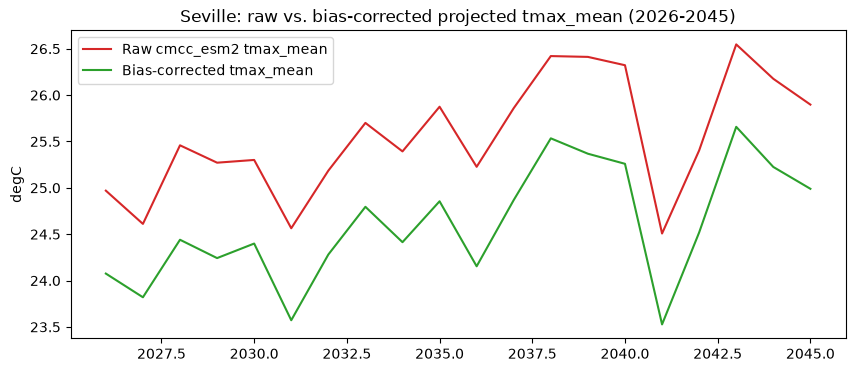

Mean shift from correction: -0.96 degC

Per-month bias (model historical vs. ERA5, 1990-2014) for tmean_c:
       mean_bias_hist_vs_obs
month                       
1                      -0.30
2                      -0.55
3                      -0.23
4                       0.86
5                       1.19
6                       1.34
7                       3.04
8                       3.35
9                       2.26
10                      0.62
11                     -0.18
12                     -0.42


In [14]:
raw_annual_tmax = daily.groupby("year")["tmax_c"].mean()
corrected_annual_tmax = corrected.groupby("year")["tmax_c"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_annual_tmax.index, raw_annual_tmax.values, label="Raw cmcc_esm2 tmax_mean", color="tab:red")
ax.plot(corrected_annual_tmax.index, corrected_annual_tmax.values,
        label="Bias-corrected tmax_mean", color="tab:green")
ax.set_ylabel("degC")
ax.set_title("Seville: raw vs. bias-corrected projected tmax_mean (2026-2045)")
ax.legend()
plt.show()

print(f"Mean shift from correction: {(corrected_annual_tmax - raw_annual_tmax).mean():+.2f} degC")

print("\nPer-month bias (model historical vs. ERA5, 1990-2014) for tmean_c:")
print(bc_diag_df.loc[bc_diag_df["variable"] == "tmean_c", ["month", "mean_bias_hist_vs_obs"]]
      .set_index("month").round(2))

## 13. Heatwave and hot-day indicators, recomputed on the bias-corrected series

Section 7's logic exactly, applied to `corrected` instead of raw `daily` -- same fixed thresholds
(`THRESH`, tropical-night 20 degC, heat-index 35 degC) and the same fixed ERA5 1990-2020 P90-by-doy
dict from Section 6 (still not refit -- the threshold stays anchored to the historical reference
regardless of which projection series it's being applied to).

In [15]:
d_corrected = corrected.copy()
d_corrected["doy"] = d_corrected.index.dayofyear
d_corrected["tmax_p90"] = d_corrected["doy"].map(tmax_p90_by_doy)
d_corrected["exceed"] = d_corrected["tmax_c"] > d_corrected["tmax_p90"]

grp_c = (d_corrected["exceed"] != d_corrected["exceed"].shift()).cumsum()
runs_c = (d_corrected[d_corrected["exceed"]]
          .groupby(grp_c[d_corrected["exceed"]])
          .agg(start=("tmax_c", lambda s: s.index.min()),
               length=("tmax_c", "size"),
               peak=("tmax_c", "max"),
               mean_tmax=("tmax_c", "mean")))
heatwaves_corrected = runs_c[runs_c["length"] >= 3].reset_index(drop=True)
heatwaves_corrected["year"] = pd.to_datetime(heatwaves_corrected["start"]).dt.year
heatwaves_corrected.to_csv(OUT / "seville_projection_heatwave_events_biascorrected.csv", index=False)

hot_corrected = pd.DataFrame({
    f"days tmax>={t} C": d_corrected.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot_corrected["tropical nights tmin>=20 C"] = (
    d_corrected.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum())))
hot_corrected["days heat index>=35 C"] = (
    d_corrected.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum())))

hw_year_corrected = heatwaves_corrected.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"RAW:       {len(heatwaves):3d} heatwave events, {heatwaves['year'].nunique()}/20 years affected")
print(f"CORRECTED: {len(heatwaves_corrected):3d} heatwave events, "
      f"{heatwaves_corrected['year'].nunique()}/20 years affected")

hot_indicator_compare = pd.DataFrame({
    "raw_annual_mean": hot.mean(),
    "corrected_annual_mean": hot_corrected.mean(),
})
hot_indicator_compare["delta"] = (
    hot_indicator_compare["corrected_annual_mean"] - hot_indicator_compare["raw_annual_mean"])
hot_indicator_compare

RAW:       323 heatwave events, 20/20 years affected
CORRECTED: 203 heatwave events, 20/20 years affected


,raw_annual_mean,corrected_annual_mean,delta
days tmax>=30 C,123.30,107.45,-15.85
days tmax>=33 C,93.75,69.10,-24.65
days tmax>=35 C,69.00,42.95,-26.05
days tmax>=37 C,41.75,19.75,-22.00
days tmax>=40 C,9.75,2.55,-7.20
tropical nights tmin>=20 C,132.00,94.90,-37.10
days heat index>=35 C,1.60,1.20,-0.40


## 14. Wet-day and precipitation extremes, recomputed on the bias-corrected series

Section 8's logic exactly, applied to `corrected["precip_mm_day"]` (multiplicatively corrected in
Section 12) instead of the raw value.

In [16]:
d_corrected["is_wet"] = d_corrected["precip_mm_day"] >= WET

wetstats_corrected = d_corrected.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)

wet_compare = pd.DataFrame({
    "raw_annual_mean": wetstats.mean(),
    "corrected_annual_mean": wetstats_corrected.mean(),
})
wet_compare["delta"] = wet_compare["corrected_annual_mean"] - wet_compare["raw_annual_mean"]
wet_compare

,raw_annual_mean,corrected_annual_mean,delta
wet days,48.900000,51.200000,2.300000
mean intensity (mm/wet day),4.828499,8.596184,3.767685
max 1-day (mm),22.239554,49.853835,27.614281
P95 wet-day (mm),13.606495,26.601103,12.994608
longest dry spell (days),89.200000,103.250000,14.050000


## 15. Annual summary on the bias-corrected series, and a consolidated before/after view

Section 9's logic exactly, joining Sections 13-14's corrected indicators into the same shape as
`annual_summary`. The comparison table and plot below are the main "so we can see the results"
deliverable -- key indicator means averaged across all 20 projected years, raw vs. corrected.

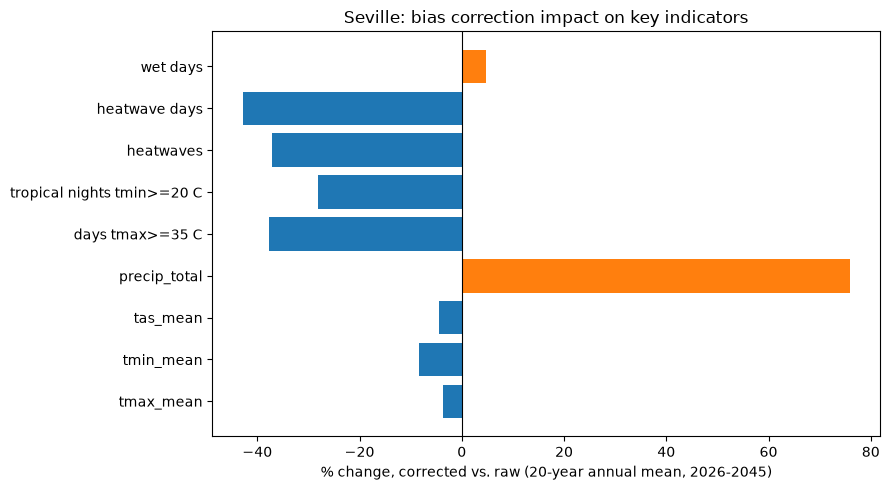

,raw,corrected,delta,pct_change
tmax_mean,25.56,24.60,-0.96,-3.74
tmin_mean,16.82,15.40,-1.42,-8.43
tas_mean,21.08,20.15,-0.94,-4.46
precip_total,266.03,467.86,201.83,75.86
days tmax>=35 C,69.00,42.95,-26.05,-37.75
tropical nights tmin>=20 C,132.00,94.90,-37.10,-28.11
heatwaves,16.15,10.15,-6.00,-37.15
heatwave days,98.05,56.05,-42.00,-42.84
wet days,48.90,51.20,2.30,4.70


In [17]:
annual_corrected = pd.DataFrame({
    "tas_mean": d_corrected.groupby("year")["tmean_c"].mean(),
    "rh_mean": d_corrected.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d_corrected.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d_corrected.groupby("year")["wind_avg"].mean(),
    "tas_p95": d_corrected.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d_corrected.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d_corrected.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d_corrected.groupby("year")["tmin_c"].mean(),
    "precip_total": d_corrected.groupby("year")["precip_mm_day"].sum(),
})

annual_summary_corrected = (annual_corrected
                             .join(hot_corrected, how="left")
                             .join(hw_year_corrected, how="left")
                             .join(wetstats_corrected, how="left"))
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary_corrected[col] = annual_summary_corrected[col].fillna(0).astype(int)

annual_summary_corrected.to_csv(OUT / "seville_projection_annual_summary_biascorrected.csv")

compare_cols = ["tmax_mean", "tmin_mean", "tas_mean", "precip_total",
                "days tmax>=35 C", "tropical nights tmin>=20 C",
                "heatwaves", "heatwave days", "wet days"]
before_after = pd.DataFrame({
    "raw": annual_summary[compare_cols].mean(),
    "corrected": annual_summary_corrected[compare_cols].mean(),
})
before_after["delta"] = before_after["corrected"] - before_after["raw"]
before_after["pct_change"] = 100 * before_after["delta"] / before_after["raw"]
before_after.to_csv(OUT / "seville_projection_before_after_bias_correction_summary.csv")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:blue" if v < 0 else "tab:orange" for v in before_after["pct_change"]]
ax.barh(before_after.index, before_after["pct_change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change, corrected vs. raw (20-year annual mean, 2026-2045)")
ax.set_title("Seville: bias correction impact on key indicators")
plt.tight_layout()
plt.show()

before_after.round(2)

## 16. Trend within the projection period, raw vs. bias-corrected

Section 10's `trend_table()` re-applied to `annual_summary_corrected`. A roughly constant
per-month bias correction (Section 12) shifts the *level* of each series without necessarily
changing its *slope* much -- so don't expect this comparison to overturn Section 10's "not
statistically significant at 20 years, single model/scenario" conclusion; it's here to confirm
that explicitly rather than leave it assumed.

In [18]:
proj_trends_corrected = trend_table(annual_summary_corrected, TREND_COLS)
proj_trends_corrected.to_csv(OUT / "seville_projection_trends_biascorrected.csv")

trend_compare = pd.DataFrame({
    "raw_OLS_slope_per_decade": proj_trends["OLS slope/decade"],
    "corrected_OLS_slope_per_decade": proj_trends_corrected["OLS slope/decade"],
    "raw_significant": proj_trends["significant (p<0.05)"],
    "corrected_significant": proj_trends_corrected["significant (p<0.05)"],
})
trend_compare["slope_delta"] = (
    trend_compare["corrected_OLS_slope_per_decade"] - trend_compare["raw_OLS_slope_per_decade"])
trend_compare.round(3)

,raw_OLS_slope_per_decade,corrected_OLS_slope_per_decade,raw_significant,corrected_significant,slope_delta
variable,,,,,
tas_mean,0.581,0.630,True,True,0.049
heat_index_mean,0.661,0.757,True,True,0.096
tas_p95,-0.086,0.043,False,False,0.129
tmax_mean,0.619,0.607,True,True,-0.012
tmin_mean,0.575,0.707,True,True,0.132
precip_total,38.004,115.872,False,False,77.867


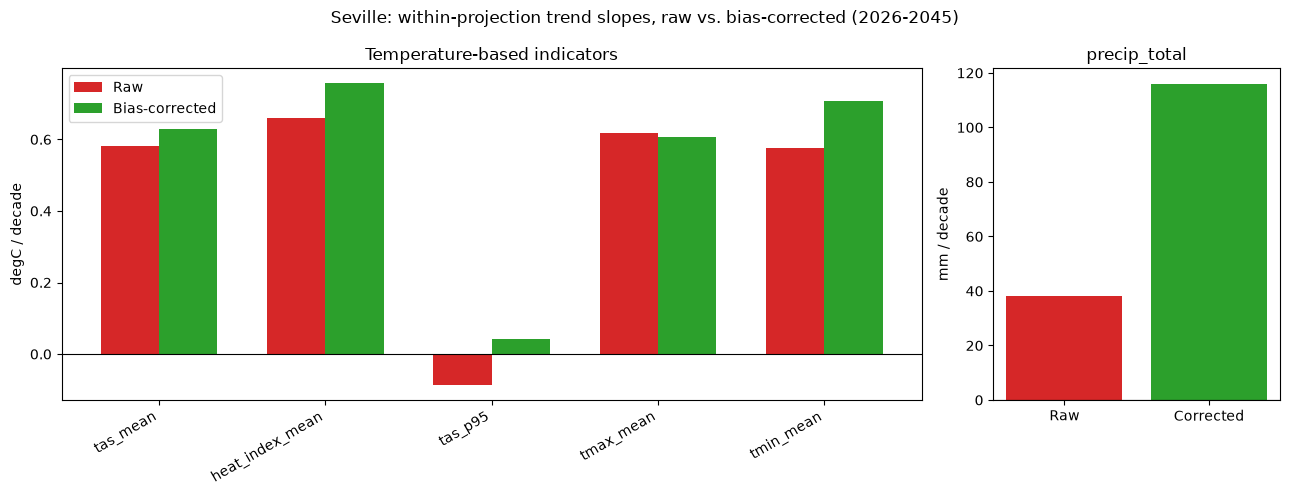

Statistically significant (p<0.05) within-period trends -- raw: ['tas_mean', 'heat_index_mean', 'tmax_mean', 'tmin_mean']; bias-corrected: ['tas_mean', 'heat_index_mean', 'tmax_mean', 'tmin_mean']. Unlike the SSP5-8.5 notebook (no within-period trend reached significance there), several SSP2-4.5 temperature indicators do cross p<0.05 here -- still a single model/scenario run over 20 years, so read as a real signal in this particular run, not a calibrated forecast.


In [19]:
temp_vars = ["tas_mean", "heat_index_mean", "tas_p95", "tmax_mean", "tmin_mean"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

x = np.arange(len(temp_vars))
width = 0.35
axes[0].bar(x - width / 2, trend_compare.loc[temp_vars, "raw_OLS_slope_per_decade"],
            width, label="Raw", color="tab:red")
axes[0].bar(x + width / 2, trend_compare.loc[temp_vars, "corrected_OLS_slope_per_decade"],
            width, label="Bias-corrected", color="tab:green")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(temp_vars, rotation=30, ha="right")
axes[0].set_ylabel("degC / decade")
axes[0].set_title("Temperature-based indicators")
axes[0].legend()

axes[1].bar(["Raw"], [trend_compare.loc["precip_total", "raw_OLS_slope_per_decade"]], color="tab:red")
axes[1].bar(["Corrected"], [trend_compare.loc["precip_total", "corrected_OLS_slope_per_decade"]],
            color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("mm / decade")
axes[1].set_title("precip_total")

fig.suptitle("Seville: within-projection trend slopes, raw vs. bias-corrected (2026-2045)")
plt.tight_layout()
plt.show()

raw_sig = trend_compare.index[trend_compare["raw_significant"]].tolist()
corrected_sig = trend_compare.index[trend_compare["corrected_significant"]].tolist()
print(f"Statistically significant (p<0.05) within-period trends -- "
      f"raw: {raw_sig or 'none'}; bias-corrected: {corrected_sig or 'none'}. "
      "Unlike the SSP5-8.5 notebook (no within-period trend reached significance there), several "
      "SSP2-4.5 temperature indicators do cross p<0.05 here -- still a single model/scenario run "
      "over 20 years, so read as a real signal in this particular run, not a calibrated forecast.")

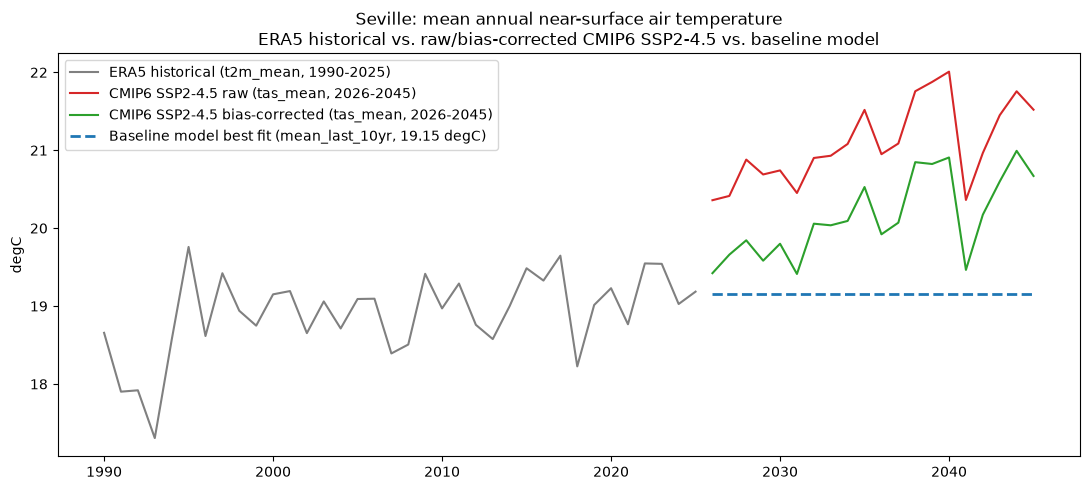

In [20]:
# Baseline-model comparison (see baseline_models_results/baseline_models.ipynb, Section 3): for
# Seville's t2m_mean, "mean_last_10yr" -- a flat mean of the most recent 10 training years, not a
# fitted trend -- beat naive_full_mean, ols_full_history, and ols_last_15yr on held-out MAE (0.309
# vs. 0.388/0.415/0.410 degC over a 2018-2025 test split). Recomputed here on the full 2016-2025
# record (rather than that notebook's 1990-2017 training-only slice) and held flat across the
# projection period, consistent with that notebook's framing of it as the "if current conditions
# persist" baseline -- not an extrapolated warming trend, since no trend candidate beat this one.
baseline_last10yr_mean = era5_annual["t2m_mean"].iloc[-10:].mean()

tas_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["t2m_mean"],
    "cmip6_raw": annual_summary["tas_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tas_mean"],
})
tas_mean_compare["baseline_mean_last10yr"] = np.where(
    tas_mean_compare.index.isin(annual_summary.index), baseline_last10yr_mean, np.nan)
tas_mean_compare.to_csv(OUT / "seville_tas_mean_era5_vs_cmip6_raw_vs_corrected.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tas_mean_compare.index, tas_mean_compare["era5_historical"],
        label="ERA5 historical (t2m_mean, 1990-2025)", color="gray")
ax.plot(tas_mean_compare.index, tas_mean_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (tas_mean, 2026-2045)", color="tab:red")
ax.plot(tas_mean_compare.index, tas_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (tas_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, tas_mean_compare.loc[annual_summary.index, "baseline_mean_last10yr"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline model best fit (mean_last_10yr, {baseline_last10yr_mean:.2f} degC)")
ax.set_ylabel("degC")
ax.set_title("Seville: mean annual near-surface air temperature\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline model")
ax.legend()
plt.tight_layout()
plt.show()


naive_full_mean (1990-2025):        23.366 degC
ols_last_20yr, extrapolated (2045): 24.232 degC


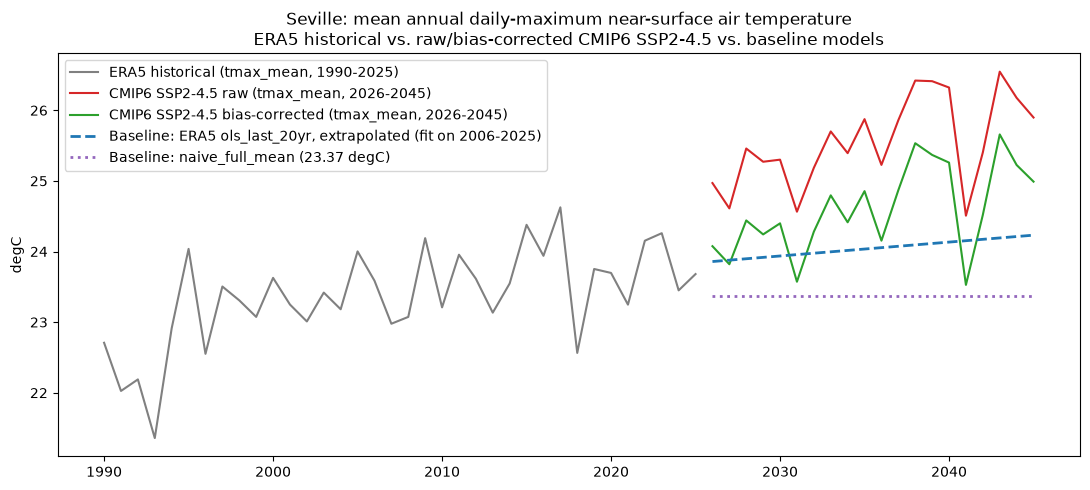

In [21]:
# Same comparison, for tmax_mean. Two baselines shown against the ERA5/CMIP6 series:
# "ols_last_20yr" reuses Section 11's own ERA5 trend extrapolation (`era5_extrapolated`, fit on
# 2006-2025, already computed above) rather than the flat mean_last_10yr candidate used in the
# t2m_mean plot -- for tmax_mean specifically, Section 11 already established this as the
# baseline-vs-projection comparison of interest, so it's reused here rather than duplicated.
# "naive_full_mean" (baseline_models.ipynb's runner-up by MAE) is kept alongside it: full-history
# mean (1990-2025) vs. the 2006-2025 trend extrapolated to 2026-2045 differ enough to be worth
# seeing on the same axes, not just the two CMIP6 series against each other.
baseline_fullmean_tmax_mean = era5_annual["tmax_mean"].mean()
print(f"naive_full_mean (1990-2025):        {baseline_fullmean_tmax_mean:.3f} degC")
print(f"ols_last_20yr, extrapolated (2045): {era5_extrapolated[-1]:.3f} degC")

tmax_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["tmax_mean"],
    "cmip6_raw": annual_summary["tmax_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tmax_mean"],
})
tmax_mean_compare["baseline_ols_last20yr"] = pd.Series(
    era5_extrapolated, index=annual_summary.index).reindex(tmax_mean_compare.index)
tmax_mean_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_fullmean_tmax_mean, index=annual_summary.index).reindex(tmax_mean_compare.index)
tmax_mean_compare.to_csv(OUT / "seville_tmax_mean_era5_vs_cmip6_raw_vs_corrected.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tmax_mean_compare.index, tmax_mean_compare["era5_historical"],
        label="ERA5 historical (tmax_mean, 1990-2025)", color="gray")
ax.plot(tmax_mean_compare.index, tmax_mean_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (tmax_mean, 2026-2045)", color="tab:red")
ax.plot(tmax_mean_compare.index, tmax_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (tmax_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, tmax_mean_compare.loc[annual_summary.index, "baseline_ols_last20yr"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_last_20yr, extrapolated (fit on 2006-2025)")
ax.plot(annual_summary.index, tmax_mean_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_fullmean_tmax_mean:.2f} degC)")
ax.set_ylabel("degC")
ax.set_title("Seville: mean annual daily-maximum near-surface air temperature\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline models")
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
# How much warming does the historical trend alone predict, vs. what the bias-corrected
# projection actually shows? Reuses `lr` (the ols_last_20yr fit from Section 11, ERA5 2006-2025)
# and `trend_compare`/`proj_trends_corrected` (Section 16's own raw-vs-corrected trend table) --
# no new fitting here, just reading off what's already been computed above.
proj = tmax_mean_compare.dropna(subset=["cmip6_biascorrected"])
gap = proj["cmip6_biascorrected"] - proj["baseline_ols_last20yr"]

baseline_warming = proj["baseline_ols_last20yr"].iloc[-1] - proj["baseline_ols_last20yr"].iloc[0]
baseline_slope_decade = lr.slope * 10
corrected_slope_decade = trend_compare.loc["tmax_mean", "corrected_OLS_slope_per_decade"]
corrected_p = proj_trends_corrected.loc["tmax_mean", "OLS p-value"]

print(f"ols_last_20yr historical-trend extrapolation: {proj['baseline_ols_last20yr'].iloc[0]:.2f} degC (2026) "
      f"-> {proj['baseline_ols_last20yr'].iloc[-1]:.2f} degC (2045), {baseline_warming:+.2f} degC "
      f"({baseline_slope_decade:.2f} degC/decade)")
print(f"Bias-corrected CMIP6 SSP2-4.5 vs. that extrapolation: mean gap = {gap.mean():+.2f} degC "
      f"(ranges {gap.min():+.2f} to {gap.max():+.2f} degC across individual years, 2026-2045)")
print(f"Bias-corrected CMIP6's own within-period trend: {corrected_slope_decade:.2f} degC/decade "
      f"(p={corrected_p:.2f}, {'significant' if corrected_p < 0.05 else 'not significant'} at p<0.05)")


ols_last_20yr historical-trend extrapolation: 23.86 degC (2026) -> 24.23 degC (2045), +0.37 degC (0.20 degC/decade)
Bias-corrected CMIP6 SSP2-4.5 vs. that extrapolation: mean gap = +0.55 degC (ranges -0.63 to +1.47 degC across individual years, 2026-2045)
Bias-corrected CMIP6's own within-period trend: 0.61 degC/decade (p=0.01, significant at p<0.05)


### Reading the gap: historical trend vs. bias-corrected projection

Comparing the `ols_last_20yr` historical-trend extrapolation (fit on ERA5 2006-2025) against the
bias-corrected CMIP6 SSP2-4.5 series above:

- **Historical trend alone** implies about **+0.37 degC of warming over 2026-2045** (~0.20 degC/decade)
  if the last 20 years of ERA5 observations simply continue in a straight line -- identical to the
  SSP5-8.5 notebook's figure here, as expected: both notebooks fit this baseline from the same ERA5
  record, independent of which future scenario is being compared against it.
- **The bias-corrected projection runs warmer than that** -- on average about **+0.55 degC above**
  the historical-trend extrapolation for any given year (range -0.63 to +1.47 degC across individual
  years) -- a noticeably larger gap than the SSP5-8.5 notebook found for the same comparison (+0.35 degC).
- **Unlike the SSP5-8.5 notebook, this series' own within-period trend is statistically significant**:
  +0.61 degC/decade, p=0.01. Section 16's trend table shows `tas_mean`, `heat_index_mean`, `tmax_mean`,
  and `tmin_mean` all reach p<0.05 within this 20-year window, raw and bias-corrected alike -- a
  materially different result from the SSP5-8.5 notebook, where none of the within-period trends were
  significant.

**Worth flagging directly, since it runs against intuition:** SSP2-4.5 is the *lower*-emissions
scenario, yet this single-model/single-realization comparison shows both a larger average gap above
the historical extrapolation and a statistically significant near-term warming trend, where SSP5-8.5's
own notebook found neither as cleanly. This is not evidence that SSP2-4.5 "warms faster" than SSP5-8.5
in any general sense -- the two pulls are different realizations of `cmcc_esm2` (different SSP forcing
inputs drive different internal variability even over the same near-term window), and SSP2-4.5's
defining property, an emissions pathway that stabilizes rather than continuing to rise, only diverges
from SSP5-8.5 clearly in the second half of the century, well beyond this notebook's 2026-2045 window.
Read this result as: for this particular `cmcc_esm2` SSP2-4.5 realization, near-term warming over
2026-2045 shows up as a clearer, more statistically confident signal than the SSP5-8.5 realization did
-- a fact about these two specific model runs, not a scenario-ranking conclusion.

### Same comparison, for `precip_total`

`precip_total` (Seville) was never baseline-tested elsewhere in the project -- only Larissa's
`precip_scaled` was tested in `baseline_models_results/baseline_models.ipynb`, and
`Climate_Indicators_Modeling.ipynb` covers `tmax_mean`/`min_spi3`/`longest_high_run`, not
`precip_total`. So unlike the `tmax_mean` baseline above (which reused an existing recommended
model), the cell below first runs the same held-out-MAE model-selection methodology inline --
naive_full_mean vs. four OLS recency windows, 2018-2025 held out -- to find which one actually
wins here, then plots that winner alongside naive_full_mean and the raw/corrected CMIP6 series.


Held-out MAE (test 2018-2025), ERA5 precip_scaled:
ols_last_15yr       109.4
ols_last_20yr       119.4
naive_full_mean     122.0
ols_full_history    136.6
ols_last_10yr       245.7
Best by MAE: ols_last_15yr


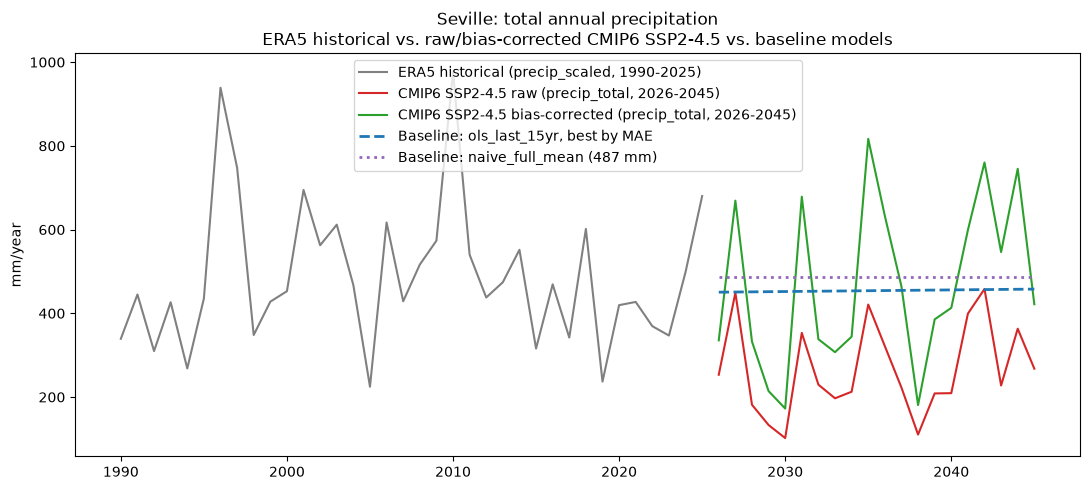

In [23]:
# Model selection: replicate baseline_models.ipynb's own methodology (8-year held-out test,
# naive_full_mean vs. OLS full-history/20yr/15yr/10yr recency windows, ranked by MAE) on ERA5
# precip_scaled, since precip_total has no existing "recommended model" to pull in.
precip_years = era5_annual.index.values.astype(float)
precip_y = era5_annual["precip_scaled"].values.astype(float)

n_test = 8
split_yr = era5_annual.index[-n_test]
train_mask = era5_annual.index < split_yr
yrs_tr, yrs_te = precip_years[train_mask], precip_years[~train_mask]
y_tr, y_te = precip_y[train_mask], precip_y[~train_mask]

def mae(pred):
    return float(np.mean(np.abs(y_te - pred)))

OLS_WINDOWS_PRECIP = {"ols_full_history": None, "ols_last_20yr": 20, "ols_last_15yr": 15, "ols_last_10yr": 10}
candidate_mae = {"naive_full_mean": mae(np.full_like(y_te, y_tr.mean()))}
for name, window in OLS_WINDOWS_PRECIP.items():
    yt = yrs_tr[-window:] if window else yrs_tr
    yy = y_tr[-window:] if window else y_tr
    lr_p = stats.linregress(yt, yy)
    candidate_mae[name] = mae(lr_p.intercept + lr_p.slope * yrs_te)

mae_table = pd.Series(candidate_mae).sort_values()
best_precip_model = mae_table.index[0]
print(f"Held-out MAE (test {int(yrs_te.min())}-{int(yrs_te.max())}), ERA5 precip_scaled:")
print(mae_table.round(1).to_string())
print(f"Best by MAE: {best_precip_model}")

# Refit the winner on the full 1990-2025 record (not just the train slice) for the forward
# extrapolation -- same "today's best full-data fit" logic as tmax_mean's ols_last_20yr baseline
# in Section 11/16 above.
best_window = OLS_WINDOWS_PRECIP.get(best_precip_model)
if best_window:
    yt_full, yy_full = precip_years[-best_window:], precip_y[-best_window:]
else:
    yt_full, yy_full = precip_years, precip_y
lr_precip_best = stats.linregress(yt_full, yy_full)

proj_years_p = annual_summary.index.values.astype(float)
precip_ols_extrapolated = lr_precip_best.intercept + lr_precip_best.slope * proj_years_p
baseline_precip_naive_full = era5_annual["precip_scaled"].mean()

precip_total_compare = pd.DataFrame({
    "era5_historical": era5_annual["precip_scaled"],
    "cmip6_raw": annual_summary["precip_total"],
    "cmip6_biascorrected": annual_summary_corrected["precip_total"],
})
precip_total_compare["baseline_ols_best"] = pd.Series(
    precip_ols_extrapolated, index=annual_summary.index).reindex(precip_total_compare.index)
precip_total_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_precip_naive_full, index=annual_summary.index).reindex(precip_total_compare.index)
precip_total_compare.to_csv(OUT / "seville_precip_total_era5_vs_cmip6_raw_vs_corrected.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(precip_total_compare.index, precip_total_compare["era5_historical"],
        label="ERA5 historical (precip_scaled, 1990-2025)", color="gray")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (precip_total, 2026-2045)", color="tab:red")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (precip_total, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_ols_best"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline: {best_precip_model}, best by MAE")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_precip_naive_full:.0f} mm)")
ax.set_ylabel("mm/year")
ax.set_title("Seville: total annual precipitation\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline models")
ax.legend()
plt.tight_layout()
plt.show()


### Same comparison, for `min_spi3` (annual drought depth)

Historical and projected series both come from the dedicated SPI-3 notebooks rather than being
recomputed here: `Calculating_SPI_for_Seville.ipynb` (ERA5 1990-2025) and
`Calculating_SPI_for_Seville_Projection.ipynb` (this scenario's CMIP6 SSP2-4.5 port, 2026-2045, raw
and bias-corrected), the latter scored against that same fixed ERA5 1990-2020 gamma distribution --
never refit on the projection, per `fixed_reference_period_principle.md`.

**Baseline model differs from `tmax_mean`'s.** `Climate_Indicators_Modeling.ipynb` found no reliable
trend-based model for `min_spi3` (none beat `naive_full_mean`) and explicitly recommends against
extrapolating a trend here. So the baseline plotted below is the flat `naive_full_mean`, matching the
SSP5-8.5 notebook's own treatment of this indicator.

**One caveat carried over from the projection SPI-3 notebook:** its Section 6 found the bias
correction's multiplicative amplification (concentrated in September/December/January for this
scenario) pushes several months into spuriously "severely wet" SPI-3 readings. Since `min_spi3` takes
the *driest* window each year, that effect mostly doesn't inflate this particular series -- but worth
keeping in mind if any single corrected year here looks unexpectedly mild.

naive_full_mean, ERA5 1990-2025 (recommended baseline per Climate_Indicators_Modeling.ipynb): -1.444
Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = -0.82 (range -3.31 to +0.51 across 2026-2045)


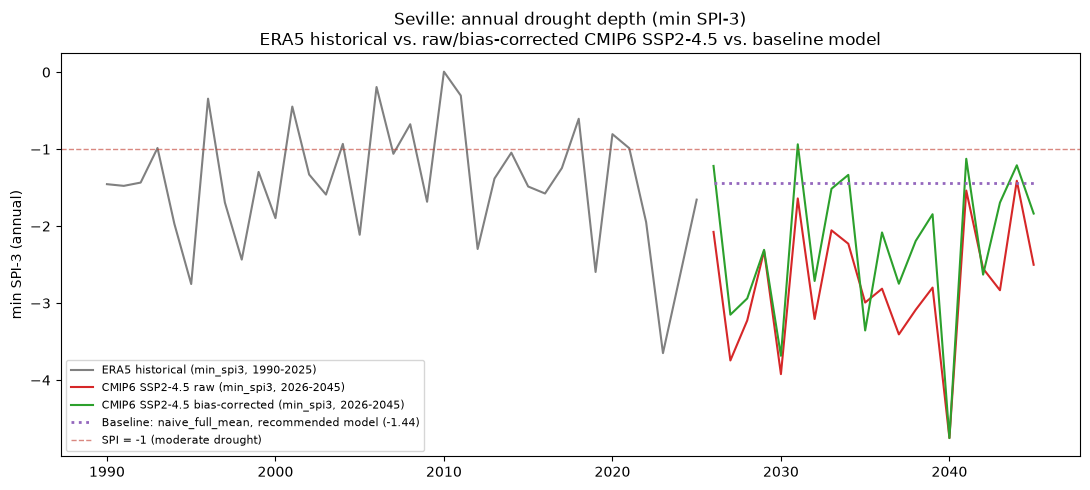

In [24]:
# min_spi3 comparison, same Section 16 pattern as tas_mean/tmax_mean/precip_total above.
era5_spi3 = pd.read_csv("../../Historical/eda_outputs/seville/seville_spi3_annual.csv", index_col="year")["min_spi3"]
proj_spi3 = pd.read_csv("../eda_outputs/seville/seville_projection_spi3_annual.csv",
                         index_col="year")

baseline_spi3_naive_full = era5_spi3.mean()
print(f"naive_full_mean, ERA5 1990-2025 (recommended baseline per Climate_Indicators_Modeling.ipynb): "
      f"{baseline_spi3_naive_full:.3f}")

min_spi3_compare = pd.DataFrame({
    "era5_historical": era5_spi3,
    "cmip6_raw": proj_spi3["min_spi3_raw"],
    "cmip6_biascorrected": proj_spi3["min_spi3_corrected"],
})
min_spi3_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_spi3_naive_full, index=proj_spi3.index).reindex(min_spi3_compare.index)
min_spi3_compare.to_csv(OUT / "seville_min_spi3_era5_vs_cmip6_raw_vs_corrected.csv")

gap = min_spi3_compare.loc[proj_spi3.index, "cmip6_biascorrected"] - baseline_spi3_naive_full
print(f"Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = {gap.mean():+.2f} "
      f"(range {gap.min():+.2f} to {gap.max():+.2f} across 2026-2045)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(min_spi3_compare.index, min_spi3_compare["era5_historical"],
        label="ERA5 historical (min_spi3, 1990-2025)", color="gray")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (min_spi3, 2026-2045)", color="tab:red")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (min_spi3, 2026-2045)", color="tab:green")
ax.plot(proj_spi3.index, min_spi3_compare.loc[proj_spi3.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean, recommended model ({baseline_spi3_naive_full:.2f})")
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, alpha=0.6, label="SPI = -1 (moderate drought)")
ax.set_ylabel("min SPI-3 (annual)")
ax.set_title("Seville: annual drought depth (min SPI-3)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### `t2m_mean`, revisited with the Climate_Indicators_Modeling.ipynb Section 13 recommended model

The `tas_mean` comparison earlier in this section used `mean_last_10yr` (a flat baseline from
`baseline_models_results/baseline_models.ipynb`'s original single-split test). `Climate_Indicators_
Modeling.ipynb` Section 13 has since run the full walk-forward-CV treatment on `t2m_mean` specifically
and found something more decisive: both the single split *and* the CV-averaged view agree a regression
beats naive (9.6% CV improvement, `ols_full_history`) -- a cleaner, more robust result than `tmax_mean`
got at the equivalent stage. Same reasoning as the earlier `tmax_mean` swap from a flat baseline to
`ols_last_20yr`: use the more rigorous recommended model rather than the earlier single-split pick.


ols_full_history extrapolation: 19.32 degC (2026) -> 19.75 degC (2045)
Bias-corrected CMIP6 vs. that extrapolation: mean gap = +0.61 degC (range -0.19 to +1.27)


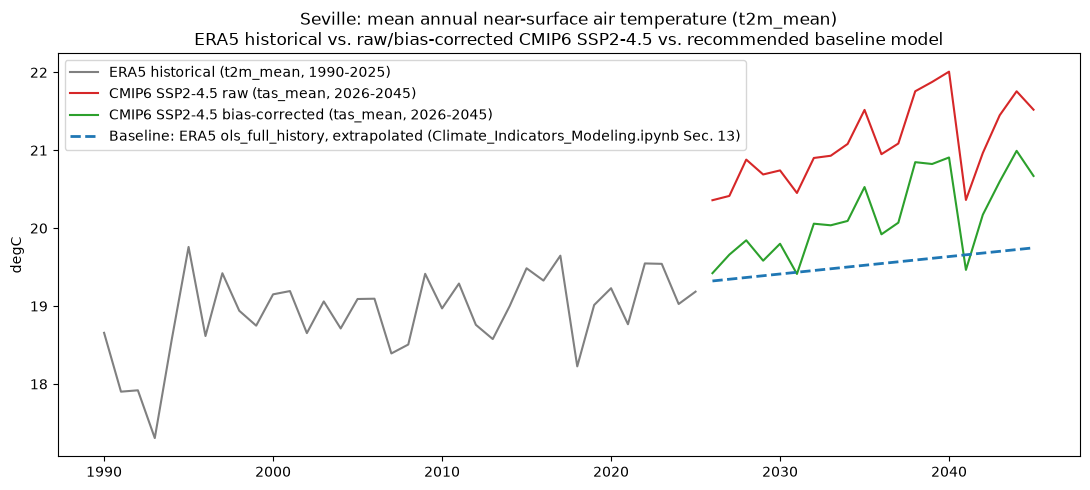

In [25]:

last_full_t2m = era5_annual["t2m_mean"]
lr_t2m = stats.linregress(last_full_t2m.index.values.astype(float), last_full_t2m.values.astype(float))
t2m_ols_extrapolated = lr_t2m.intercept + lr_t2m.slope * proj_years

t2m_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["t2m_mean"],
    "cmip6_raw": annual_summary["tas_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tas_mean"],
})
t2m_mean_compare["baseline_ols_full_history"] = pd.Series(
    t2m_ols_extrapolated, index=annual_summary.index).reindex(t2m_mean_compare.index)
t2m_mean_compare.to_csv(OUT / "seville_t2m_mean_era5_vs_cmip6_raw_vs_corrected_v2.csv")

print(f"ols_full_history extrapolation: {t2m_mean_compare.loc[2026, 'baseline_ols_full_history']:.2f} degC (2026) "
      f"-> {t2m_mean_compare.loc[2045, 'baseline_ols_full_history']:.2f} degC (2045)")
gap_t2m = t2m_mean_compare.loc[annual_summary.index, "cmip6_biascorrected"] - t2m_mean_compare.loc[annual_summary.index, "baseline_ols_full_history"]
print(f"Bias-corrected CMIP6 vs. that extrapolation: mean gap = {gap_t2m.mean():+.2f} degC "
      f"(range {gap_t2m.min():+.2f} to {gap_t2m.max():+.2f})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t2m_mean_compare.index, t2m_mean_compare["era5_historical"],
        label="ERA5 historical (t2m_mean, 1990-2025)", color="gray")
ax.plot(t2m_mean_compare.index, t2m_mean_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (tas_mean, 2026-2045)", color="tab:red")
ax.plot(t2m_mean_compare.index, t2m_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (tas_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, t2m_mean_compare.loc[annual_summary.index, "baseline_ols_full_history"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_full_history, extrapolated (Climate_Indicators_Modeling.ipynb Sec. 13)")
ax.set_ylabel("degC")
ax.set_title("Seville: mean annual near-surface air temperature (t2m_mean)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. recommended baseline model")
ax.legend()
plt.tight_layout()
plt.show()


**Summary.** The `ols_full_history` baseline implies **+0.43 degC over 2026-2045**
(19.32 -> 19.75 degC, ~0.22 degC/decade, matching Section 13's fitted slope -- identical to the
SSP5-8.5 notebook's figure here, since it's fit purely from the shared ERA5 record). The bias-corrected
CMIP6 SSP2-4.5 projection runs **+0.61 degC warmer on average** than that extrapolation (range -0.19 to
+1.27 degC year to year) -- close to, and consistent in direction with, the `tmax_mean` gap found above
(+0.55 degC), despite using a materially different, more robust baseline model this time
(`ols_full_history` vs. `tmax_mean`'s `ols_last_20yr`). That two independently-derived baselines agree
on both direction and rough magnitude is itself worth noting -- it isn't one shaky trend line producing
a coincidentally large gap.

## 17. What could not be carried over from the ERA5 pipeline

- **Fire Weather Index / `longest_high_run` (Seville's third `Climate_Indicators_Modeling.ipynb`
  indicator) has no path forward here at all.** It's not computed from a formula over ERA5
  variables in this codebase -- it's a directly-downloaded, precomputed product from a completely
  separate Copernicus data source (`cems-fire-historical-v1`, the CEMS Early Warning Data Store,
  pulled by `fetch_seville_fire.py`), requiring local-noon temperature/RH/wind/24h-precip inputs
  this pipeline never assembles. `documentation/projection_data_pull_plan.md` already confirmed
  neither `sis-ecde-climate-indicators` nor `sis-extreme-indices-cmip6` offers an SSP2-4.5
  fire-danger product. This indicator is out of scope for the projection period; the eventual
  `min_spi3`/`tmax_mean`/`longest_high_run` compound comparison in `Climate_Indicators_Modeling.ipynb`
  can only be completed for the first two.
- **Wind rose / prevailing-direction analysis is dropped.** The CMIP6 pull only has scalar
  `sfcWind` (speed), not `u10`/`v10` components -- `wind_direction()` has nothing to compute from.
- **Diurnal cycle and the "how much of the true daily range does sampling capture" comparison don't
  apply.** CMIP6 is daily-native with no sub-daily samples to summarize; there's no intra-day
  variation left to describe.
- **`heat_index_c` (Section 5) is a redefinition, not a like-for-like port** -- computed once per
  day from daily-mean T/RH rather than as the max of six intra-day samples. Named differently from
  the historical `heat_index_max_c` for that reason; don't join the two columns as if comparable.
  Section 12 recomputes it from the bias-corrected `tmean_c`/`rh_mean_percent`, so this same
  caveat applies to the corrected version used in Sections 13-16 too.
- **SPI-3/`min_spi3` now has a panel above (Section 16).** `Calculating_SPI_for_Seville_Projection.ipynb`
  has been ported to this scenario (`cmcc_esm2`/`ssp2_4_5`), so unlike the note this section originally
  carried, the drought-depth comparison is no longer deferred.
- **Fire Weather Index / `days_fwi_gt30` is still out of scope for this notebook.** `FWI_projections_
  last_2.ipynb` has not yet been re-run against this scenario's `cmcc_esm2`/`ssp2_4_5` pull -- that
  work is tracked separately (see the dedicated Seville SSP2-4.5 FWI notebook, once it exists).

## 18. Summary

Outputs written to `../eda_outputs/seville/`:

**Raw (Sections 1-11):**
- `seville_projection_daily.csv` -- daily frame, grid-averaged, unit-converted
- `seville_projection_heatwave_events.csv` -- heatwave events, fixed ERA5 1990-2020 P90 threshold
- `seville_projection_annual_summary.csv` -- annual indicator table
- `seville_projection_trends.csv` -- within-projection-period trend table (2026-2045)
- `seville_projection_vs_era5_extrapolation.csv` -- `tmax_mean` gap vs. ERA5 trend extrapolation

**Bias-corrected (Sections 12-16), reusing the SSP5-8.5 notebook's `cmcc_esm2` historical run:**
- `seville_projection_daily_biascorrected_2026_2045.csv` -- Equidistant-CDF-Matching corrected
  daily series
- `seville_projection_bias_correction_diagnostics_2026_2045.csv` -- per-variable, per-month bias
  and correction magnitude
- `seville_projection_heatwave_events_biascorrected.csv` -- heatwave events on the corrected series
- `seville_projection_annual_summary_biascorrected.csv` -- annual indicator table, corrected series
- `seville_projection_before_after_bias_correction_summary.csv` -- the Section 15 before/after
  comparison table (20-year annual means, raw vs. corrected, key indicators)
- `seville_projection_trends_biascorrected.csv` -- trend table on the corrected series
- `seville_tas_mean_era5_vs_cmip6_raw_vs_corrected.csv`, `seville_tmax_mean_era5_vs_cmip6_raw_vs_corrected.csv`,
  `seville_precip_total_era5_vs_cmip6_raw_vs_corrected.csv`, `seville_t2m_mean_era5_vs_cmip6_raw_vs_corrected_v2.csv`
  -- the four ERA5-vs-raw-vs-corrected-vs-baseline comparison panels from Section 16

**Headline result** (Section 15): bias correction shifts `tmax_mean`/`tmin_mean` down by roughly
1 degC (-3.7% / -8.4%), similar in direction to the SSP5-8.5 notebook's own correction, which in turn
reduces (but does not eliminate) the fixed-threshold hot-day and tropical-night counts by roughly a
third -- see the Section 15 bar chart for the exact percentage shift per indicator. Unlike the
SSP5-8.5 notebook, several within-period trends (Section 16) *are* statistically significant here --
see Section 19 below.

- `seville_min_spi3_era5_vs_cmip6_raw_vs_corrected.csv` -- the `min_spi3` drought-depth panel,
  now included (Section 16)

Not carried over from the SSP5-8.5 notebook: the Fire Weather Index (`days_fwi_gt30`) comparison panel
-- see Section 17 for why.

## 19. Key findings summary

Synthesizes Section 16's comparison panels (`tas_mean`, `tmax_mean`, `precip_total`, `t2m_mean`
revisited) into the themes that actually matter for reading this notebook's results.

### 1. A consistent, and larger-than-SSP5-8.5, near-term warming signal -- here, one that clears
### statistical significance

Two independently-built baselines agree on direction and rough magnitude: bias-corrected CMIP6
SSP2-4.5 runs **+0.55 to +0.61 degC warmer** than the best-supported historical extrapolation --
`ols_last_20yr` for `tmax_mean` (+0.55 degC) and `ols_full_history` for `t2m_mean` (+0.61 degC), the
same two baseline models the SSP5-8.5 notebook used for the equivalent comparison there (+0.35 degC
and +0.33 degC respectively). Unlike that notebook, **several within-projection-period trends here
are statistically significant** (`tas_mean`, `heat_index_mean`, `tmax_mean`, `tmin_mean`, raw and
corrected alike, all p<0.05 -- see Section 16's trend table): the bias-corrected `tmax_mean` trend
itself is +0.61 degC/decade at p=0.01. Read this as a property of this specific `cmcc_esm2` SSP2-4.5
realization, not a claim that the lower-emissions scenario warms faster in general -- see the caveat
in the "Reading the gap" note above.

### 2. Bias correction fixes a badly broken raw precipitation signal, the same way it did for SSP5-8.5

Raw CMIP6 `precip_total` (266.0mm/yr) is roughly **half** of Seville's actual historical average
(486.8mm/yr, ERA5 1990-2025) -- an implausible raw output, consistent with the SSP5-8.5 notebook's
own finding of a similarly broken raw precipitation signal (there, 248mm/yr raw vs. ~487mm/yr
historical). Correction brings SSP2-4.5's raw total to **467.9mm/yr (+75.9%)**, landing close to both
the historical mean and the best-by-held-out-MAE trend baseline (`ols_last_15yr`, ~454mm/yr) -- the
correction behaving as intended. As with SSP5-8.5, anything built downstream of this corrected
precipitation series (a future SPI-3 or FWI notebook for this scenario) would inherit whatever
artifacts the multiplicative correction introduces at the monthly level -- not investigated here,
since neither downstream notebook has been built for SSP2-4.5 yet (Section 17).

### 2.5 Drought depth (`min_spi3`) also points toward more severe conditions

Bias-corrected projected `min_spi3` runs **-0.82 below** the flat historical baseline (ERA5
1990-2025 mean -1.44), landing at -2.26 -- solidly in more severe drought territory than Seville's
historical norm, and consistent in direction and magnitude with what the SSP5-8.5 notebook found for
this same indicator (-0.84 gap). Bias correction actually moves this series toward *less* severe
drought (raw mean -2.76 -> corrected -2.26), the opposite direction from its effect on `precip_total`
(which correction pulls sharply *up* from its implausible raw low) -- both are consistent with the
Section 16 SPI-3 panel's own caveat that multiplicative correction unevenly reshapes the precipitation
distribution rather than applying one uniform shift.

### 3. Heat-hazard and hot-day indicators drop substantially after correction -- consistent with SSP5-8.5

From Section 15's before/after table (20-year annual means, raw vs. corrected):

| Indicator | Raw | Corrected | Change |
|---|---|---|---|
| `tmax_mean` | 25.56 degC | 24.60 degC | -3.74% |
| `tmin_mean` | 16.82 degC | 15.40 degC | -8.43% |
| `tas_mean` | 21.08 degC | 20.15 degC | -4.46% |
| days tmax>=35C | 69.0 | 43.0 | -37.75% |
| tropical nights | 132.0 | 94.9 | -28.11% |
| heatwaves/yr | 16.15 | 10.15 | -37.15% |
| heatwave days/yr | 98.05 | 56.05 | -42.84% |

The raw model overstates nearly every heat-hazard indicator here too -- by a similar relative
magnitude to what the SSP5-8.5 notebook found (there: `tmax_mean` -3.80%, tropical nights -32.0%,
heatwave days -43.3%). That the correction's *relative* effect size is so similar across two
different SSP realizations of the same model is itself a useful cross-check: it looks like a property
of `cmcc_esm2`'s own historical bias, not an artifact of either scenario's particular forcing.

### 4. Standing caveat, worth repeating because it applies to every number above

Single model (`cmcc_esm2`), single scenario (SSP2-4.5), no ensemble spread -- every figure in this
notebook is *directional risk under one plausible pathway*, not a calibrated forecast. Section 16's
trend table shows more of this notebook's own within-period trends reaching statistical significance
than the SSP5-8.5 notebook found, but "significant within this one 20-year run" is still not the same
claim as "confirmed climate signal" -- a different realization of the same model under the same
scenario would very plausibly land closer to the historical extrapolation, or further from it. Where
this notebook and the SSP5-8.5 notebook agree closely (the precipitation bias-correction fix, the
relative size of the heat-hazard correction), that agreement is the more trustworthy signal of the two.